# 04_statistical_baseline.ipynb — Statistical Baseline Analysis

**Project:** MachineMind AI  
**Component:** `ml-service`  
**Phase:** Phase 6 — Statistical Baseline  
**Target Dataset:** NASA IMS Bearing Dataset (Set 2)  

---

## 1. Executive Summary & Objective

This notebook executes the non-machine-learning statistical baseline analysis for **IMS Set 2**. 

The goal is to quantify vibration signal deviations across 984 sequential 1-second snapshots using simple, transparent statistical metrics fitted strictly on an initial chronological fitting period.

### Chronological Dataset Partitioning
1. **Baseline Fitting Period (Snapshots 0 to 159, N=160, ~26.7 hrs):**
   Used strictly to fit baseline distribution parameters ($\mu, \sigma, \text{median}, \text{MAD}$). Represents a provisional reference baseline (*not independently confirmed healthy*).
2. **Reference Evaluation Period (Snapshots 160 to 199, N=40, ~6.7 hrs):**
   Evaluated with frozen baseline parameters to observe baseline stability on unseen provisional reference data (*not confirmed healthy*).
3. **Sequential Evaluation Period (Snapshots 200 to 983, N=784, ~130.7 hrs):**
   Evaluated sequentially with frozen baseline parameters to monitor long-term degradation trajectories to test completion.

> **Methodological Note:** Thresholds 3.0 and 3.5 are **provisional reference boundaries**, not calibrated failure thresholds. The dataset documents a single run-to-failure experiment; results do not constitute failure prediction or Remaining Useful Life (RUL) estimation.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Locate project root directory
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.baseline import fit_baseline_parameters, compute_composite_anomaly_scores

print(f"Project Root: {PROJECT_ROOT}")


Project Root: D:\Projects\MachineMind AI\ml-service


## 2. Load Processed Feature Matrix

We load the 36 statistical features extracted in Phase 5 stored at `data/processed/features_set2.csv`.


In [2]:
features_path = PROJECT_ROOT / "data" / "processed" / "features_set2.csv"
df_features = pd.read_csv(features_path)

print(f"Feature Matrix Shape: {df_features.shape}")
print(f"Total Snapshots: {len(df_features)}")
print(f"Sample Columns: {list(df_features.columns[:8])} ...")


Feature Matrix Shape: (984, 40)
Total Snapshots: 984
Sample Columns: ['file_index', 'filename', 'timestamp', 'is_valid', 'ch1_mean', 'ch1_std', 'ch1_rms', 'ch1_p2p'] ...


## 3. Fit Frozen Baseline Parameters

We fit feature mean, standard deviation, median, MAD, IQR, and peak-to-peak range strictly using the first 160 snapshots (`ref_end_idx=160`).


In [3]:
ref_end_idx = 160
baseline_params = fit_baseline_parameters(df_features, ref_end_idx=ref_end_idx)

print("Baseline Parameters Fitting Summary:")
print(f"  - Fitting Window: Snapshots 0 to {baseline_params['ref_end_idx'] - 1} (N={baseline_params['ref_end_idx']})")
print(f"  - Total Features Processed: {len(baseline_params['feature_names'])}")
print(f"  - Eligible Z-score Features: {len(baseline_params['eligible_z_features'])}")
print(f"  - Eligible Modified Z-score Features: {len(baseline_params['eligible_m_features'])}")
print(f"  - Excluded Features: {len(baseline_params['excluded_z_features'])}")


Baseline Parameters Fitting Summary:
  - Fitting Window: Snapshots 0 to 159 (N=160)
  - Total Features Processed: 36
  - Eligible Z-score Features: 36
  - Eligible Modified Z-score Features: 36
  - Excluded Features: 0


## 4. Compute Composite Anomaly Scores

Using the frozen baseline parameters, we evaluate all 984 snapshots across four composite metrics:
1. `score_max_z`: Maximum absolute Z-score across features.
2. `score_rms_z`: RMS composite Z-score across features.
3. `score_max_m`: Maximum absolute modified Z-score across features.
4. `score_rms_m`: RMS composite modified Z-score across features.


In [4]:
df_scores = compute_composite_anomaly_scores(df_features, baseline_params)

print(f"Computed Scores Matrix Shape: {df_scores.shape}")
df_scores[["file_index", "filename", "score_max_z", "score_rms_z", "score_max_m", "score_rms_m"]].head()


Computed Scores Matrix Shape: (984, 8)


,file_index,filename,score_max_z,score_rms_z,score_max_m,score_rms_m
0,0,2004.02.12.10.32.39,11.408886,4.452465,27.476769,9.003799
1,1,2004.02.12.10.42.39,3.313614,1.402935,3.744407,1.661694
2,2,2004.02.12.10.52.39,3.458684,1.507638,4.841946,1.933746
3,3,2004.02.12.11.02.39,8.348248,3.183660,13.273196,4.345198
4,4,2004.02.12.11.12.39,1.977210,0.928966,2.059358,1.045030


## 5. Statistical Summary across Partition Periods

We examine score statistics across the three chronological partitions to observe baseline stability and degradation trends.


In [5]:
fit_part = df_scores.iloc[:160]
ref_eval_part = df_scores.iloc[160:200]
seq_eval_part = df_scores.iloc[200:]

summary_data = []
for name, part in [("Baseline Fitting (0-159)", fit_part), 
                   ("Reference Eval (160-199)", ref_eval_part), 
                   ("Sequential Eval (200-983)", seq_eval_part)]:
    summary_data.append({
        "Partition Period": name,
        "N Snapshots": len(part),
        "Mean score_rms_z": part["score_rms_z"].mean(),
        "Max score_rms_z": part["score_rms_z"].max(),
        "Mean score_rms_m": part["score_rms_m"].mean(),
        "Max score_rms_m": part["score_rms_m"].max(),
    })

df_summary = pd.DataFrame(summary_data)
df_summary


,Partition Period,N Snapshots,Mean score_rms_z,Max score_rms_z,Mean score_rms_m,Max score_rms_m
0,Baseline Fitting (0-159),160,0.920520,4.452465,1.086143,9.003799
1,Reference Eval (160-199),40,0.969576,1.447295,1.090505,1.919485
2,Sequential Eval (200-983),784,12.304339,400.943788,13.014866,449.166859


## 6. Export Baseline Scores Dataset

Export the composite scores dataset to `data/processed/baseline_scores_set2.csv`.


In [6]:
export_cols = ["file_index", "filename", "timestamp", "is_valid", "score_max_z", "score_rms_z", "score_max_m", "score_rms_m"]
df_export = df_scores[export_cols].copy()

out_path = PROJECT_ROOT / "data" / "processed" / "baseline_scores_set2.csv"
df_export.to_csv(out_path, index=False)

print(f"Successfully exported scores to: {out_path}")
print(f"Exported Dimensions: {df_export.shape}")


Successfully exported scores to: D:\Projects\MachineMind AI\ml-service\data\processed\baseline_scores_set2.csv
Exported Dimensions: (984, 8)


## 7. Score Trajectory Visualizations

Plot composite anomaly scores over time with partition boundaries at snapshot indices 160 and 200, alongside provisional reference threshold lines at 3.0 and 3.5.


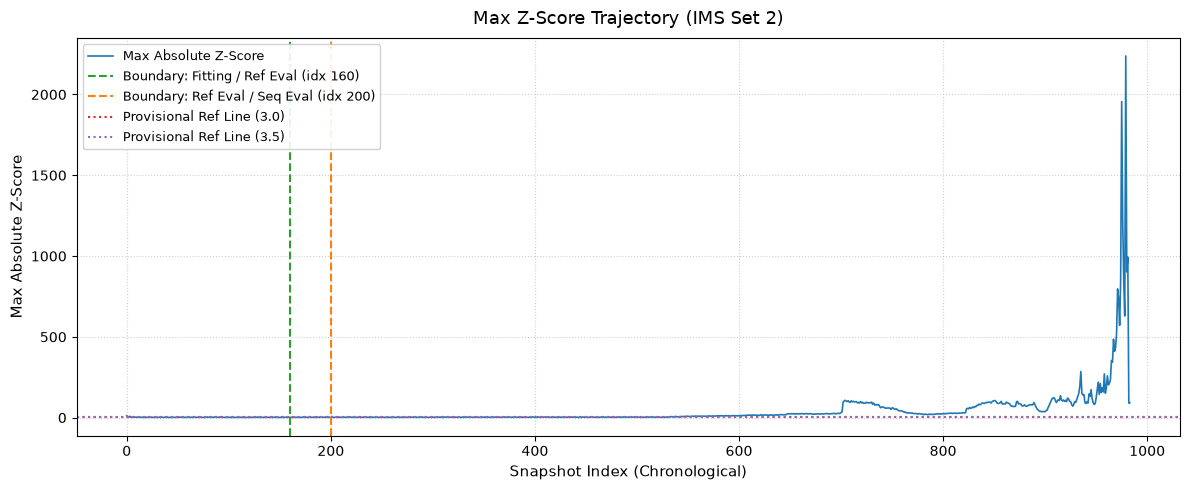

Saved figure: D:\Projects\MachineMind AI\ml-service\reports\figures\baseline\baseline_score_max_z.png


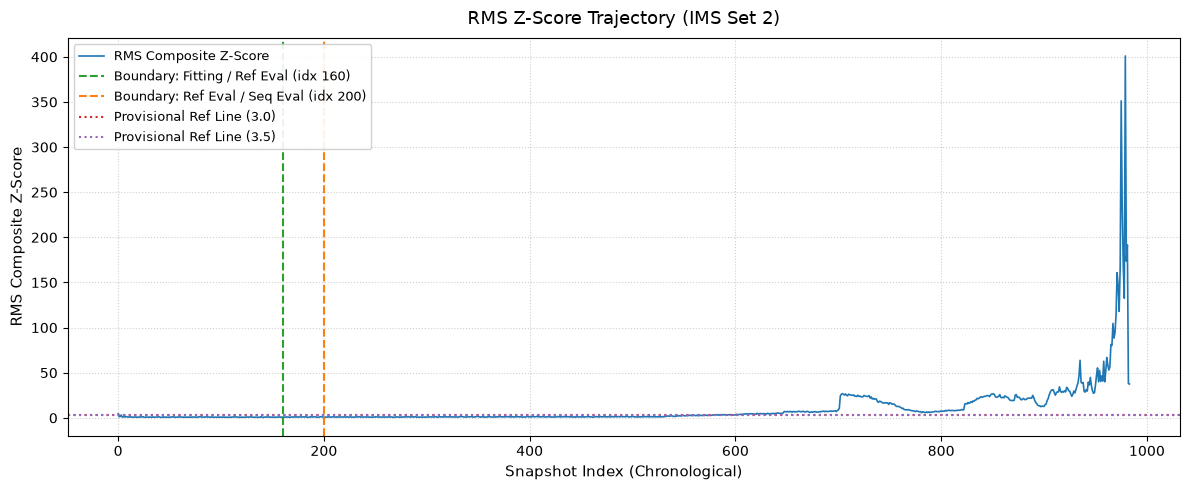

Saved figure: D:\Projects\MachineMind AI\ml-service\reports\figures\baseline\baseline_score_rms_z.png


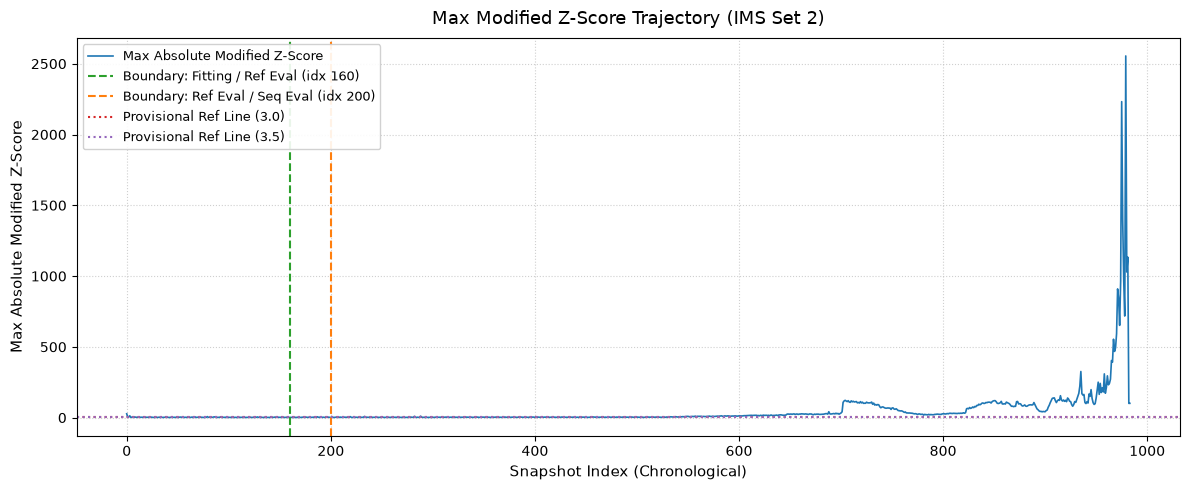

Saved figure: D:\Projects\MachineMind AI\ml-service\reports\figures\baseline\baseline_score_max_m.png


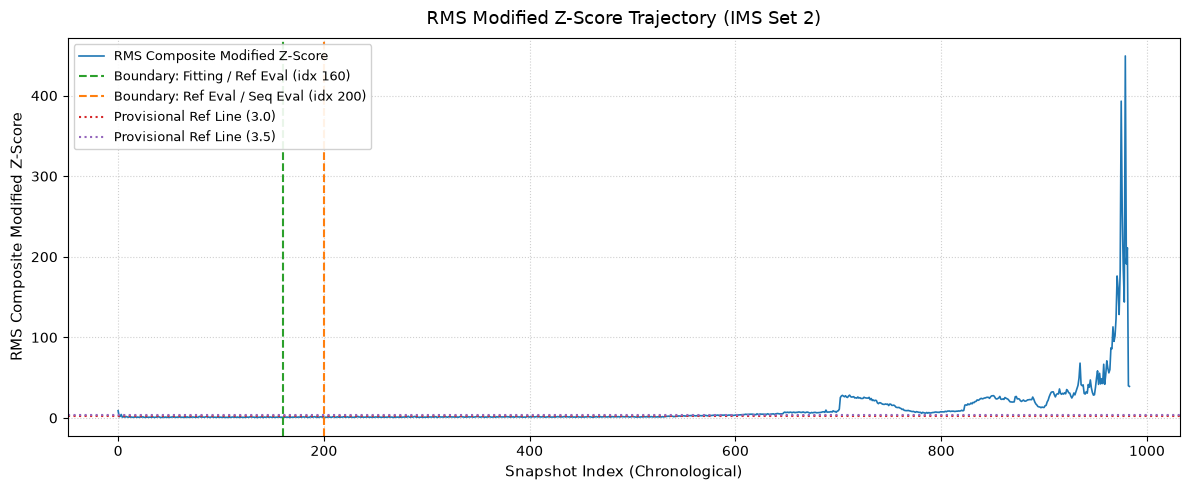

Saved figure: D:\Projects\MachineMind AI\ml-service\reports\figures\baseline\baseline_score_rms_m.png


In [7]:
fig_dir = PROJECT_ROOT / "reports" / "figures" / "baseline"
fig_dir.mkdir(parents=True, exist_ok=True)

plot_configs = [
    ("score_max_z", "Max Absolute Z-Score", "baseline_score_max_z.png", "Max Z-Score Trajectory (IMS Set 2)"),
    ("score_rms_z", "RMS Composite Z-Score", "baseline_score_rms_z.png", "RMS Z-Score Trajectory (IMS Set 2)"),
    ("score_max_m", "Max Absolute Modified Z-Score", "baseline_score_max_m.png", "Max Modified Z-Score Trajectory (IMS Set 2)"),
    ("score_rms_m", "RMS Composite Modified Z-Score", "baseline_score_rms_m.png", "RMS Modified Z-Score Trajectory (IMS Set 2)"),
]

for score_col, ylabel, filename, title in plot_configs:
    plt.figure(figsize=(12, 5))
    plt.plot(df_export["file_index"], df_export[score_col], label=ylabel, color="#1f77b4", linewidth=1.2)
    
    # Chronological partition boundaries
    plt.axvline(x=160, color="#2ca02c", linestyle="--", linewidth=1.5, label="Boundary: Fitting / Ref Eval (idx 160)")
    plt.axvline(x=200, color="#ff7f0e", linestyle="--", linewidth=1.5, label="Boundary: Ref Eval / Seq Eval (idx 200)")
    
    # Provisional reference threshold lines
    plt.axhline(y=3.0, color="#d62728", linestyle=":", linewidth=1.5, label="Provisional Ref Line (3.0)")
    plt.axhline(y=3.5, color="#9467bd", linestyle=":", linewidth=1.5, label="Provisional Ref Line (3.5)")
    
    plt.title(title, fontsize=13, pad=10)
    plt.xlabel("Snapshot Index (Chronological)", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    
    fig_path = fig_dir / filename
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"Saved figure: {fig_path}")


## 8. Empirical Integrity & Reload Verification

Validate exported file dimensions, row order, finite score values, and reload safety.


In [8]:
df_reloaded = pd.read_csv(out_path)

assert len(df_reloaded) == 984, f"Expected 984 rows, got {len(df_reloaded)}"
assert list(df_reloaded.columns) == export_cols, f"Unexpected columns: {list(df_reloaded.columns)}"
assert not df_reloaded.isna().any().any(), "Reloaded dataset contains NaN values!"
assert np.isfinite(df_reloaded[["score_max_z", "score_rms_z", "score_max_m", "score_rms_m"]].to_numpy()).all(), "Scores contain non-finite values!"
assert (df_reloaded["file_index"] == np.arange(984)).all(), "File indices are out of chronological order!"

pd.testing.assert_series_equal(df_reloaded["filename"], df_features["filename"])
pd.testing.assert_series_equal(df_reloaded["timestamp"], df_features["timestamp"])

print("✓ All 7 empirical validation checks passed cleanly!")


✓ All 7 empirical validation checks passed cleanly!
